In [12]:
import os
# The jupyter notebook is launched from your $HOME directory.
# Change the working directory to your username directory under /scratch/cd82
os.chdir(os.path.expandvars("/scratch/cd82/$USER/"))

# Image Classification with Convolutional Neural Networks

## Episode 04 Compile and Train (Fit) a Convolutional Neural Network

### Improve Model Generalization (avoid Overfitting)

In [13]:
# load the required packages
from tensorflow import keras # data and neural network
from sklearn.model_selection import train_test_split # data splitting
import matplotlib.pyplot as plt # plotting
import seaborn as sns # specialised plotting
import pandas as pd # handles dataframes

In [14]:
# function to prepare the training dataset
def prepare_dataset(train_images, train_labels):
    
    # normalize the RGB values to be between 0 and 1
    train_images = train_images / 255.0
    
    # one hot encode the training labels
    train_labels = keras.utils.to_categorical(train_labels, len(class_names))
    
    # split the training data into training and validation set
    train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size = 0.2, random_state=42)

    return train_images, val_images, train_labels, val_labels

In [15]:
# load the data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# create a list of classnames
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# prepare the dataset for training
train_images, val_images, train_labels, val_labels = prepare_dataset(train_images, train_labels)

## Improve Model Generalization (avoid Overfitting)

### Dropout

## CHALLENGE Create a function that defines a CNN with Dropout

Use the `create_model_intro()` definition as the template, create a new function called `create_model_dropout()`

Hint 1: Add one Dropout Layer that randomly drops 50 per cent of the input units.

Hint 2: Consider adding an additional layer(s) from one of the four layers we discussed.

In [16]:
#     Dropout Model Definition

#     INPUT: 32x32 images with three channels (RGB)
#     Layer 1: convolutional, 16 filters, 3x3 kernel, ReLU activation
#     Layer 2: max pooling, 2x2 window
#     Layer 3: convolutional, 32 filters, 3x3 kernel, ReLU activation
#     Layer 4: max pooling, 2x2 window
#     Layer 5: convolutional, 64 filters, 3x3 kernel, ReLU activation
#     Layer 6: dropout layer, 50% of input units
#     Layer 7: flatten to 1D
#     Layer 8: dense layer, 64 units, ReLU activation
#     OUTPUT: dense layer, 10 units (one per class), softmax activation


In [17]:
## SOLUTION


## Solution

In [18]:
# function to define the dropout model
def create_model_dropout():
    
    # CNN Part 1
    # Input layer of 32x32 images with three channels (RGB)
    inputs_dropout = keras.Input(shape=train_images.shape[1:])
    
    # CNN Part 2
    # Convolutional layer with 16 filters, 3x3 kernel size, and ReLU activation
    x_dropout = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu')(inputs_dropout)
    # Pooling layer with input window sized 2x2
    x_dropout = keras.layers.MaxPooling2D(pool_size=(2,2))(x_dropout)
    # Second Convolutional layer with 32 filters, 3x3 kernel size, and ReLU activation
    x_dropout = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(x_dropout)
    # Second Pooling layer with input window sized 2x2
    x_dropout = keras.layers.MaxPooling2D(pool_size=(2,2))(x_dropout)
    # Third Convolutional layer with 64 filters, 3x3 kernel size, and ReLU activation
    x_dropout = keras.layers.Conv2D(64, (3, 3), activation='relu')(x_dropout) # This is new!
    # Dropout layer andomly drops 50 per cent of the input units
    x_dropout = keras.layers.Dropout(rate=0.5)(x_dropout) # This is new!
    # Flatten layer to convert 2D feature maps into a 1D vector
    x_dropout = keras.layers.Flatten()(x_dropout)
    x_dropout = keras.layers.Dense(units=64, activation='relu')(x_dropout)

    
    # CNN Part 3
    # Output layer with 10 units (one for each class) and softmax activation
    outputs_dropout = keras.layers.Dense(units=10, activation='softmax')(x_dropout)
    
    # create the model
    model_dropout = keras.Model(inputs = inputs_dropout, 
                              outputs = outputs_dropout,
                              name = "cifar_model_dropout")
    
    return model_dropout

## CHALLENGE Does adding Dropout improve our model?

1. Create the dropout model.

2. Write the code to compile and fit our new dropout model using the same arguments we used for our model in the introduction.

3. Inspect the training metrics to determine whether the model has improved.

4. Save the dropout model.

5. Monitor the training progress.

In [19]:
## SOLUTION


## SOLUTION

Epoch 1/10
1250/1250 [==============================] - 9s 5ms/step - loss: 1.6509 - categorical_accuracy: 0.3911 - val_loss: 1.3696 - val_categorical_accuracy: 0.5047
Epoch 2/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.3399 - categorical_accuracy: 0.5178 - val_loss: 1.2043 - val_categorical_accuracy: 0.5665
Epoch 3/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.2324 - categorical_accuracy: 0.5579 - val_loss: 1.1145 - val_categorical_accuracy: 0.6074
Epoch 4/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.1552 - categorical_accuracy: 0.5878 - val_loss: 1.0573 - val_categorical_accuracy: 0.6220
Epoch 5/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.0940 - categorical_accuracy: 0.6113 - val_loss: 1.0483 - val_categorical_accuracy: 0.6323
Epoch 6/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.0482 - categorical_accuracy: 0.6288 - val_loss: 0.9851 - val_categorical_accuracy:

<Axes: >

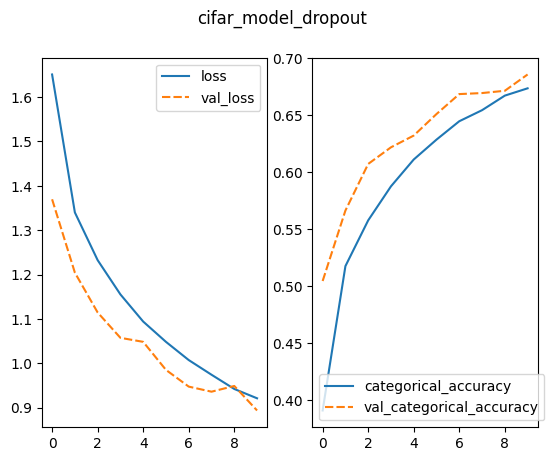

In [20]:
# create the dropout model
model_dropout = create_model_dropout()

# compile the model
model_dropout.compile(optimizer = keras.optimizers.Adam(),
                      loss = keras.losses.CategoricalCrossentropy(),
                      metrics = keras.metrics.CategoricalAccuracy())

# fit the model
history_dropout = model_dropout.fit(x = train_images, y = train_labels,
                                  batch_size = 32,
                                  epochs = 10,
                                  validation_data = (val_images, val_labels))


# save dropout model
model_dropout.save('model_dropout.keras')

# inspect the training results

# convert the history to a dataframe for plotting 
history_dropout_df = pd.DataFrame.from_dict(history_dropout.history)

# plot the loss and accuracy from the training process
fig, axes = plt.subplots(1, 2)
fig.suptitle('cifar_model_dropout')
sns.lineplot(ax=axes[0], data=history_dropout_df[['loss', 'val_loss']])
sns.lineplot(ax=axes[1], data=history_dropout_df[['categorical_accuracy', 'val_categorical_accuracy']])